In [ ]:
pip install pyspark

Dự đoán khả năng đơn hàng bị giao trễ hạn

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
from pyspark.sql.types import DoubleType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator, RegressionEvaluator

# Khởi tạo Spark với cấu hình chịu tải cao và chống Timeout
spark = SparkSession.builder \
    .appName("Olist_Advanced_Classification") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.network.timeout", "1200s") \
    .config("spark.python.worker.timeout", "1200s") \
    .config("spark.executor.heartbeatInterval", "200s") \
    .config("spark.sql.shuffle.partitions", "20") \
    .getOrCreate()

hdfs_path = "hdfs://localhost:9000/bigdata/"

orders_df = spark.read.csv(hdfs_path + "olist_orders_dataset.csv", header=True, inferSchema=True)
items_df = spark.read.csv(hdfs_path + "olist_order_items_dataset.csv", header=True, inferSchema=True)
products_df = spark.read.csv(hdfs_path + "olist_products_dataset.csv", header=True, inferSchema=True)
customers_df = spark.read.csv(hdfs_path + "olist_customers_dataset.csv", header=True, inferSchema=True)

In [2]:
orders_clean = orders_df.filter(
    (col("order_status") == "delivered") & 
    col("order_delivered_customer_date").isNotNull() & 
    col("order_estimated_delivery_date").isNotNull()
)

orders_with_label = orders_clean.withColumn(
    "label", 
    when(col("order_delivered_customer_date") > col("order_estimated_delivery_date"), 1).otherwise(0)
)

df_joined = orders_with_label.join(items_df, "order_id", "inner") \
                             .join(products_df, "product_id", "inner") \
                             .join(customers_df, "customer_id", "inner")

raw_data = df_joined.select(
    "customer_state", 
    "product_category_name", 
    col("price").cast("double"), 
    col("freight_value").cast("double"), 
    "label"
).dropna()

train_data, test_data = raw_data.randomSplit([0.8, 0.2], seed=42)
train_data.cache()

DataFrame[customer_state: string, product_category_name: string, price: double, freight_value: double, label: int]

In [3]:
state_indexer = StringIndexer(inputCol="customer_state", outputCol="state_indexed", handleInvalid="keep")
category_indexer = StringIndexer(inputCol="product_category_name", outputCol="category_indexed", handleInvalid="keep")

state_encoder = OneHotEncoder(inputCol="state_indexed", outputCol="state_encoded")
category_encoder = OneHotEncoder(inputCol="category_indexed", outputCol="category_encoded")

numerical_cols = ["price", "freight_value"]
categorical_encoded_cols = ["state_encoded", "category_encoded"]
assembler = VectorAssembler(inputCols=numerical_cols + categorical_encoded_cols, outputCol="features")

preprocessing_stages = [state_indexer, category_indexer, state_encoder, category_encoder, assembler]

In [4]:
from pyspark.ml.functions import vector_to_array

rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=30, maxDepth=6, seed=42)
rf_pipeline = Pipeline(stages=preprocessing_stages + [rf])
rf_model = rf_pipeline.fit(train_data)

rf_predictions = rf_model.transform(test_data)
rf_predictions_eval = rf_predictions.withColumn("prob_class_1", vector_to_array(col("probability"))[1])

acc_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
f1_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
roc_eval = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="probability", metricName="areaUnderROC")
rmse_eval = RegressionEvaluator(labelCol="label", predictionCol="prob_class_1", metricName="rmse")

print("--- KẾT QUẢ RANDOM FOREST ---")
print(f"Accuracy:  {acc_eval.evaluate(rf_predictions):.4f}")
print(f"F1-Score:  {f1_eval.evaluate(rf_predictions):.4f}")
print(f"ROC-AUC:   {roc_eval.evaluate(rf_predictions):.4f}")
print(f"RMSE:      {rmse_eval.evaluate(rf_predictions_eval):.4f}")

--- KẾT QUẢ RANDOM FOREST ---
Accuracy:  0.9192
F1-Score:  0.8804
ROC-AUC:   0.6153
RMSE:      0.2716


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc

y_true = np.array(rf_predictions.select("label").collect()).reshape(-1)
y_pred = np.array(rf_predictions.select("prediction").collect()).reshape(-1)

y_prob = np.array(rf_predictions_eval.select("prob_class_1").collect()).reshape(-1)

cm = confusion_matrix(y_true, y_pred)

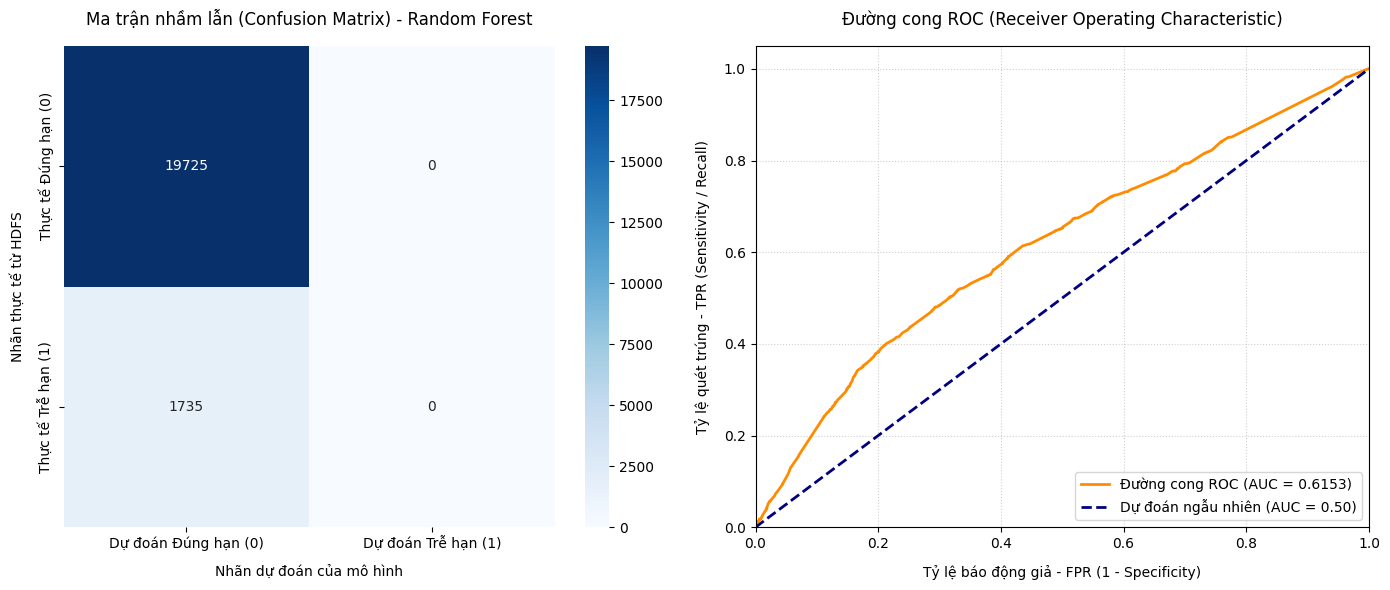

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Dự đoán Đúng hạn (0)', 'Dự đoán Trễ hạn (1)'],
            yticklabels=['Thực tế Đúng hạn (0)', 'Thực tế Trễ hạn (1)'])

ax1.set_title('Ma trận nhầm lẫn (Confusion Matrix) - Random Forest', fontsize=12, pad=15)
ax1.set_xlabel('Nhãn dự đoán của mô hình', fontsize=10, labelpad=10)
ax1.set_ylabel('Nhãn thực tế từ HDFS', fontsize=10, labelpad=10)

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'Đường cong ROC (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Dự đoán ngẫu nhiên (AUC = 0.50)')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Tỷ lệ báo động giả - FPR (1 - Specificity)', fontsize=10, labelpad=10)
ax2.set_ylabel('Tỷ lệ quét trúng - TPR (Sensitivity / Recall)', fontsize=10, labelpad=10)
ax2.set_title('Đường cong ROC (Receiver Operating Characteristic)', fontsize=12, pad=15)

ax2.grid(True, linestyle=':', alpha=0.6)

ax2.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()